In [2]:
import re
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 토크나이제이션

legal_sentence = '법원은 피고인에게 징역 3년과 벌금 500만원을 선고했다'
tokens = legal_sentence.split()
reg_tokens = re.findall(r'[가-힣A-Za-z0-9]+', legal_sentence)
print(f'원문 : {legal_sentence}')
print('\n공백기준')
print(tokens)
print(f'개수 : {len(tokens)}')
print('\n정규표현식 토큰')
print(reg_tokens)
print(f'개수 : {len(reg_tokens)}')

legal_keyword = ['법원','피고인','징역','벌금','선고']
keyword_presence = { keyword : keyword in legal_sentence for keyword in legal_keyword}
print('\n법률 핵심어 포함 여부:')
print(keyword_presence)


원문 : 법원은 피고인에게 징역 3년과 벌금 500만원을 선고했다

공백기준
['법원은', '피고인에게', '징역', '3년과', '벌금', '500만원을', '선고했다']
개수 : 7

정규표현식 토큰
['법원은', '피고인에게', '징역', '3년과', '벌금', '500만원을', '선고했다']
개수 : 7

법률 핵심어 포함 여부:
{'법원': True, '피고인': True, '징역': True, '벌금': True, '선고': True}


In [ ]:
# 간이 임베딩 과 의미유사도 : 임베딩(문자를 숫자로 바꿈) 과정을 확인
# BOW(Bag of Words) 표현으로 실습

embedding_examples = pd.DataFrame([
    {'id': 'S1', 'label': 'PROC', 'text': '위반한 자는 3년 이하의 징역 또는 벌금에 처한다.'},
    {'id': 'S2', 'label': 'PROC', 'text': '거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.'},
    {'id': 'S3', 'label': 'ORG', 'text': '분쟁 조정을 위하여 조정위원회를 설치한다.'},
    {'id': 'S4', 'label': 'ORG', 'text': '위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.'},
    {'id': 'S5', 'label': 'RIGHT', 'text': '근로자는 안전한 환경에서 일할 권리를 가진다.'},
])
# 간이임베딩
vocabulary = ['징역', '벌금', '처한다', '위원회', '설치', '구성', '권리', '근로자', '안전']

for word in vocabulary:
    embedding_examples[word] = embedding_examples['text'].str.contains(word).astype(int)

vector_columns = vocabulary
print('문장별 간이 임베딩 벡터')
print(embedding_examples[['id','label','text'] + vector_columns])

def cosine_similarity(vec_a, vec_b):
    a = np.array(vec_a, dtype=float)
    b = np.array(vec_b, dtype=float)
    denomiator = np.linalg.norm(a) * np.linalg.norm(b)
    if denomiator == 0:
        return 0.0
    return float(np.dot(a,b) / denomiator)

similarity_rows = []
for i in range(len(embedding_examples)):
    row_i = embedding_examples.iloc[i]
    for j in range(i+1, len(embedding_examples)):        
        row_j = embedding_examples.iloc[j]
        sim = cosine_similarity(row_i[vector_columns],row_j[vector_columns])
        similarity_rows.append({
            'pair' : f'{row_i["id"]}-{row_j["id"]}',
            'labels' : f'{row_i["label"]}-{row_j["label"]}',
            'simularity' : round(sim,3),
            'text_a': row_i['text'],
            'text_b': row_j['text']
        })

similarity_df = pd.DataFrame(similarity_rows).sort_values('simularity',ascending=False)
similarity_df


문장별 간이 임베딩 벡터
   id  label                                  text  징역  벌금  처한다  위원회  설치  구성  \
0  S1   PROC          위반한 자는 3년 이하의 징역 또는 벌금에 처한다.   1   1    1    0   0   0   
1  S2   PROC         거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.   0   1    1    0   0   0   
2  S3    ORG               분쟁 조정을 위하여 조정위원회를 설치한다.   0   0    0    1   1   0   
3  S4    ORG  위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.   0   0    0    1   0   1   
4  S5  RIGHT             근로자는 안전한 환경에서 일할 권리를 가진다.   0   0    0    0   0   0   

   권리  근로자  안전  
0   0    0   0  
1   0    0   0  
2   0    0   0  
3   0    0   0  
4   1    1   1  


,pair,labels,simularity,text_a,text_b
0,S1-S2,PROC-PROC,0.816,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.
7,S3-S4,ORG-ORG,0.500,분쟁 조정을 위하여 조정위원회를 설치한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
1,S1-S3,PROC-ORG,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,분쟁 조정을 위하여 조정위원회를 설치한다.
2,S1-S4,PROC-ORG,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
4,S2-S3,PROC-ORG,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,분쟁 조정을 위하여 조정위원회를 설치한다.
3,S1-S5,PROC-RIGHT,0.000,위반한 자는 3년 이하의 징역 또는 벌금에 처한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
5,S2-S4,PROC-ORG,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.
6,S2-S5,PROC-RIGHT,0.000,거짓 신고를 한 자는 1천만원 이하의 벌금에 처한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
8,S3-S5,ORG-RIGHT,0.000,분쟁 조정을 위하여 조정위원회를 설치한다.,근로자는 안전한 환경에서 일할 권리를 가진다.
9,S4-S5,ORG-RIGHT,0.000,위원회는 위원장 1명을 포함하여 15명 이내의 위원으로 구성한다.,근로자는 안전한 환경에서 일할 권리를 가진다.


In [12]:
# LLM 작동 원리 - 자동회귀식 다음 토큰 예측
# 앞의 토큰을 보고 다음 토큰을 예측한다는 규칙모델을 실습
# 실제로 llm 거대한 신경망으로 다음 토큰을 예측 
# 우리는 법률문장 몇개에서 bigram빈도를 세어서 특정토큰뒤에 어떤 토큰이 자주나오는지 확인

autoregressive_corpus = [
    '이 법은 국민의 권리를 보호함을 목적으로 한다',
    '이 법은 개인정보를 안전하게 보호함을 목적으로 한다',
    '위원회는 분쟁 조정을 위하여 설치한다',
    '위원회는 위원장 1명을 포함하여 구성한다',
    '위반한 자는 벌금에 처한다',
    '위반한 자는 징역에 처한다',
]
def tokenize_for_bigram(text):
    return re.findall(f'[가-힣A-Za-z09]+',text)

# 현재 토큰이 주어졌을때 다음 토큰이 무엇인지 빈도수 계산
bigram_counts = {}
for sentence in autoregressive_corpus:
    tokens = ['<START>'] + tokenize_for_bigram(sentence) + ['<END>']
    for current_token, next_token in zip(tokens, tokens[1:]):  # <START>, '이'   '이','법은'
        bigram_counts.setdefault(current_token,Counter())[next_token] += 1
print('특정 토큰 뒤에 올 가능성인 높은 후보')
for token in ['<START>', '이','법은','위원회는','위반한','자는' ]:
    print(f'{token} -> {bigram_counts.get(token,Counter()).most_common()}')

def generate_by_bigram(seed_token, max_steps=8):
    current = seed_token
    generated = [] if seed_token == '<START>' else [seed_token]
    trace = []
    for _ in range(max_steps):
        candidates = bigram_counts.get(current, Counter())
        if not candidates:
            break
        next_token, count = candidates.most_common(1)[0]
        trace.append({'context': ' '.join(generated) if generated else '<START>', 'next_token': next_token, 'count': count})
        if next_token == '<END>':
            break
        generated.append(next_token)
        current = next_token
    return ' '.join(generated), pd.DataFrame(trace)

특정 토큰 뒤에 올 가능성인 높은 후보
<START> -> [('이', 2), ('위원회는', 2), ('위반한', 2)]
이 -> [('법은', 2)]
법은 -> [('국민의', 1), ('개인정보를', 1)]
위원회는 -> [('분쟁', 1), ('위원장', 1)]
위반한 -> [('자는', 2)]
자는 -> [('벌금에', 1), ('징역에', 1)]


In [13]:
generated_text, generated_trace = generate_by_bigram('<START>')
print('\n생성결과')
print(generated_text)
print('\n생성과정')
print(generated_trace)


생성결과
이 법은 국민의 권리를 보호함을 목적으로 한다

생성과정
                     context next_token  count
0                    <START>          이      2
1                          이         법은      2
2                       이 법은        국민의      1
3                   이 법은 국민의        권리를      1
4               이 법은 국민의 권리를       보호함을      1
5          이 법은 국민의 권리를 보호함을       목적으로      2
6     이 법은 국민의 권리를 보호함을 목적으로         한다      2
7  이 법은 국민의 권리를 보호함을 목적으로 한다      <END>      2


In [14]:
# 법률 데이터 특성  - 중첩성, 맥락의존성,도메인특화성
keyword_rules = {
    'DEF': ['목적', '정의', '뜻', '말한다', '적용한다', '범위'],
    'ORG': ['위원회', '기관', '법원', '설치', '구성', '관장', '지휘'],
    'CRIT': ['기준', '요건', '자격', '이상', '이하', '이내', '자본금'],
    'PROC': ['신청', '심사', '조사', '청문', '소송', '절차', '징역', '벌금', '처한다', '취소', '청구'],
    'RIGHT': ['권리', '의무', '하여야 한다', '금지', '책임', '침해', '차별'],
    'ETC': ['시행', '공포', '경과', '부칙', '대통령령으로 정한다'],
}

def matched_categories(text, rules):
    result = {}
    for category, keywords in rules.items():
        hits = [keyword for keyword in keywords if keyword in text]
        if hits:
            result[category] = hits
    return result

legal_difficulty_cases = pd.DataFrame([
    {
        'case': '중첩성',
        'context': '',
        'text': '개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.',
        'point': '권리, 의무, 절차 신호가 한 문장에 함께 등장한다.',
    },
    {
        'case': '맥락 의존성',
        'context': '제2조 정의',
        'text': '공공기관이란 국가기관과 지방자치단체를 말한다.',
        'point': '본문만 봐도 DEF에 가깝지만 조항 제목이 있으면 더 확실해진다.',
    },
    {
        'case': '맥락 의존성',
        'context': '부칙',
        'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.',
        'point': '본문의 적용한다는 DEF 신호처럼 보이지만 부칙 맥락에서는 ETC에 가깝다.',
    },
    {
        'case': '도메인 특화성',
        'context': '',
        'text': '항소인은 판결서가 송달된 날부터 2주 이내에 상고장을 제출할 수 있다.',
        'point': '항소인, 판결서, 송달, 상고장 같은 법률 절차 용어가 핵심 단서다.',
    },
])

domain_terms = ['개인정보처리자', '정보주체', '청구', '공공기관', '부칙', '개정규정', '항소인', '판결서', '송달', '상고장']

legal_difficulty_cases['matched_categories'] = legal_difficulty_cases['text'].apply(lambda text: matched_categories(text, keyword_rules))
legal_difficulty_cases['matched_category_count'] = legal_difficulty_cases['matched_categories'].apply(len)
legal_difficulty_cases['domain_terms'] = legal_difficulty_cases['text'].apply(lambda text: [term for term in domain_terms if term in text])
legal_difficulty_cases['domain_term_count'] = legal_difficulty_cases['domain_terms'].apply(len)

result_table = legal_difficulty_cases[['case', 'context', 'text', 'matched_categories', 'matched_category_count', 'domain_terms', 'point']]
print('출력 해석:')
print('- 중첩성 사례는 한 문장에 RIGHT, PROC 신호가 동시에 들어가서 matched_categories가 둘 이상으로 잡힙니다.')
print('- 맥락 의존성 사례는 본문만 보면 DEF 또는 ETC처럼 보이지만, 조항 제목(context)이 있어야 의미가 더 분명해집니다.')
print('- 도메인 특화성 사례는 일반 문장보다 법률 용어가 많이 들어 있어 domain_terms와 matched_category_count가 함께 늘어납니다.')
print('- 즉, 법률 분류는 키워드 한 개만 보는 문제가 아니라, 문장 내 신호의 중첩과 조항 전체 맥락을 함께 봐야 한다는 점을 보여줍니다.')
result_table

출력 해석:
- 중첩성 사례는 한 문장에 RIGHT, PROC 신호가 동시에 들어가서 matched_categories가 둘 이상으로 잡힙니다.
- 맥락 의존성 사례는 본문만 보면 DEF 또는 ETC처럼 보이지만, 조항 제목(context)이 있어야 의미가 더 분명해집니다.
- 도메인 특화성 사례는 일반 문장보다 법률 용어가 많이 들어 있어 domain_terms와 matched_category_count가 함께 늘어납니다.
- 즉, 법률 분류는 키워드 한 개만 보는 문제가 아니라, 문장 내 신호의 중첩과 조항 전체 맥락을 함께 봐야 한다는 점을 보여줍니다.


,case,context,text,matched_categories,matched_category_count,domain_terms,point
0,중첩성,,개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.,"{'PROC': ['절차', '청구'], 'RIGHT': ['하여야 한다']}",2,"[개인정보처리자, 정보주체, 청구]","권리, 의무, 절차 신호가 한 문장에 함께 등장한다."
1,맥락 의존성,제2조 정의,공공기관이란 국가기관과 지방자치단체를 말한다.,"{'DEF': ['말한다'], 'ORG': ['기관']}",2,[공공기관],본문만 봐도 DEF에 가깝지만 조항 제목이 있으면 더 확실해진다.
2,맥락 의존성,부칙,제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.,"{'DEF': ['적용한다'], 'ETC': ['시행']}",2,[개정규정],본문의 적용한다는 DEF 신호처럼 보이지만 부칙 맥락에서는 ETC에 가깝다.
3,도메인 특화성,,항소인은 판결서가 송달된 날부터 2주 이내에 상고장을 제출할 수 있다.,{'CRIT': ['이내']},1,"[항소인, 판결서, 송달, 상고장]","항소인, 판결서, 송달, 상고장 같은 법률 절차 용어가 핵심 단서다."


In [15]:
# 카테고리 정의표
category_info = [
    {
        'code': 'DEF',
        'name': '정의 및 범위',
        'decision_rule': '법의 목적, 용어 정의, 적용 범위를 설명한다.',
        'signals': ['목적', '정의', '뜻한다', '적용', '범위'],
    },
    {
        'code': 'RIGHT',
        'name': '권리 및 의무',
        'decision_rule': '권리, 의무, 금지, 책임을 규정한다.',
        'signals': ['권리', '의무', '하여야 한다', '금지', '책임'],
    },
    {
        'code': 'PROC',
        'name': '절차 및 처벌',
        'decision_rule': '신청, 심사, 조사, 불복, 처벌, 제재 절차를 규정한다.',
        'signals': ['신청', '심사', '절차', '징역', '벌금', '처한다'],
    },
    {
        'code': 'ORG',
        'name': '조직 및 기구',
        'decision_rule': '기관, 위원회, 법원 등 조직의 설치, 구성, 권한을 규정한다.',
        'signals': ['위원회', '기관', '설치', '구성', '권한'],
    },
    {
        'code': 'CRIT',
        'name': '기준 및 요건',
        'decision_rule': '자격, 기준, 요건, 기간, 수치 조건을 제시한다.',
        'signals': ['기준', '요건', '자격', '이상', '이하'],
    },
    {
        'code': 'ETC',
        'name': '기타 조항',
        'decision_rule': '시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항이다.',
        'signals': ['시행', '부칙', '경과조치', '대통령령', '공포'],
    },
]

category_df = pd.DataFrame(category_info)
category_df

,code,name,decision_rule,signals
0,DEF,정의 및 범위,"법의 목적, 용어 정의, 적용 범위를 설명한다.","[목적, 정의, 뜻한다, 적용, 범위]"
1,RIGHT,권리 및 의무,"권리, 의무, 금지, 책임을 규정한다.","[권리, 의무, 하여야 한다, 금지, 책임]"
2,PROC,절차 및 처벌,"신청, 심사, 조사, 불복, 처벌, 제재 절차를 규정한다.","[신청, 심사, 절차, 징역, 벌금, 처한다]"
3,ORG,조직 및 기구,"기관, 위원회, 법원 등 조직의 설치, 구성, 권한을 규정한다.","[위원회, 기관, 설치, 구성, 권한]"
4,CRIT,기준 및 요건,"자격, 기준, 요건, 기간, 수치 조건을 제시한다.","[기준, 요건, 자격, 이상, 이하]"
5,ETC,기타 조항,"시행일, 경과조치, 위임 등 위 범주로 보기 어려운 조항이다.","[시행, 부칙, 경과조치, 대통령령, 공포]"


In [16]:
# 실습용 법률 조항 데이터셋 - 실제는 수집 및 기타등등...
sample_data = [
    {'id': 'D01', 'category': 'DEF', 'text': '이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.'},
    {'id': 'D02', 'category': 'DEF', 'text': '이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.'},
    {'id': 'D03', 'category': 'DEF', 'text': '공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.'},
    {'id': 'D04', 'category': 'DEF', 'text': '이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.'},
    {'id': 'R01', 'category': 'RIGHT', 'text': '모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 아니한다.'},
    {'id': 'R02', 'category': 'RIGHT', 'text': '사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.'},
    {'id': 'R03', 'category': 'RIGHT', 'text': '근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.'},
    {'id': 'R04', 'category': 'RIGHT', 'text': '누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.'},
    {'id': 'P01', 'category': 'PROC', 'text': '이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.'},
    {'id': 'P02', 'category': 'PROC', 'text': '신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.'},
    {'id': 'P03', 'category': 'PROC', 'text': '장관은 위반 사실을 조사한 후 청문 절차를 거쳐 등록을 취소할 수 있다.'},
    {'id': 'P04', 'category': 'PROC', 'text': '불법행위로 인한 손해배상 청구는 민사소송법에서 정한 절차에 따른다.'},
    {'id': 'O01', 'category': 'ORG', 'text': '분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.'},
    {'id': 'O02', 'category': 'ORG', 'text': '위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.'},
    {'id': 'O03', 'category': 'ORG', 'text': '법원은 사법권을 행사하며 대법원, 고등법원 및 지방법원으로 구성된다.'},
    {'id': 'O04', 'category': 'ORG', 'text': '중앙행정기관의 장은 소관 사무를 관장하고 소속 공무원을 지휘한다.'},
    {'id': 'C01', 'category': 'CRIT', 'text': '후보자는 선거일 현재 25세 이상인 국민이어야 한다.'},
    {'id': 'C02', 'category': 'CRIT', 'text': '지원 자격은 해당 분야 경력 3년 이상 및 학사 학위 이상으로 한다.'},
    {'id': 'C03', 'category': 'CRIT', 'text': '안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다.'},
    {'id': 'C04', 'category': 'CRIT', 'text': '허가를 받으려는 자는 자본금 1억원 이상과 전담 인력 2명 이상을 갖추어야 한다.'},
    {'id': 'E01', 'category': 'ETC', 'text': '이 법은 공포 후 6개월이 경과한 날부터 시행한다.'},
    {'id': 'E02', 'category': 'ETC', 'text': '이 법 시행 당시 종전의 규정에 따라 한 처분은 이 법에 따른 처분으로 본다.'},
    {'id': 'E03', 'category': 'ETC', 'text': '이 법의 시행에 필요한 사항은 대통령령으로 정한다.'},
    {'id': 'E04', 'category': 'ETC', 'text': '제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.'},
]

def simple_tokenize(text):
    return re.findall(r'[가-힣A-Za-z0-9]+', text)

df = pd.DataFrame(sample_data)
df['length'] = df['text'].str.len()
df['tokens'] = df['text'].apply(simple_tokenize)
df['token_count'] = df['tokens'].str.len()

print(f'데이터셋 크기: {len(df)}건')
print(f'카테고리 수: {df["category"].nunique()}개')
df.head(8)

데이터셋 크기: 24건
카테고리 수: 6개


,id,category,text,length,tokens,token_count
0,D01,DEF,이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.,43,"[이, 법은, 국민의, 기본적, 인권을, 보호하고, 자유와, 평등을, 실현함을, 목...",11
1,D02,DEF,이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.,29,"[이, 법에서, 사용하는, 용어의, 뜻은, 다음, 각, 호와, 같다]",9
2,D03,DEF,"공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다.",41,"[공공기관이란, 국가기관, 지방자치단체, 및, 법령에, 따라, 설치된, 기관을, 말한다]",9
3,D04,DEF,이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.,38,"[이, 법은, 대한민국, 영역, 안에서, 이루어지는, 정보, 처리, 행위에, 적용한다]",10
4,R01,RIGHT,"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ...",51,"[모든, 국민은, 법, 앞에, 평등하며, 성별, 종교, 또는, 사회적, 신분에, 의...",14
5,R02,RIGHT,사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.,30,"[사업자는, 이용자의, 개인정보를, 안전하게, 관리하여야, 한다]",6
6,R03,RIGHT,근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.,33,"[근로자는, 안전하고, 건강한, 근무, 환경에서, 일할, 권리를, 가진다]",8
7,R04,RIGHT,누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.,38,"[누구든지, 정당한, 사유, 없이, 타인의, 통신비밀을, 침해하여서는, 아니, 된다]",9


In [21]:
# 데이터가 특정 카테고리에 치우쳐있는지 길이차이가 큰지 확인
# 분류데이터의 불균형(자주등장하는 라벨을 선호), 길이가 특정 라벨과 강하게 연결되면 모델이
# 의미보다 길이에 의존
category_counts = df['category'].value_counts().sort_index()
length_stats = df.groupby('category')[['length','token_count']].agg(['count','mean','min','max','std']).round(2)
print('카테고리별 샘플개수')
print(category_counts)
print('\n카테고리별 길이/토큰수 통계')
print(length_stats)

카테고리별 샘플개수
category
CRIT     4
DEF      4
ETC      4
ORG      4
PROC     4
RIGHT    4
Name: count, dtype: int64

카테고리별 길이/토큰수 통계
         length                      token_count                     
          count   mean min max   std       count   mean min max   std
category                                                             
CRIT          4  38.75  29  45  7.14           4  10.50   7  12  2.38
DEF           4  37.75  29  43  6.18           4   9.75   9  11  0.96
ETC           4  34.25  28  43  7.50           4   9.75   7  14  3.10
ORG           4  35.00  31  38  2.94           4   7.75   7   8  0.50
PROC          4  39.75  37  42  2.06           4  10.75   8  12  1.89
RIGHT         4  38.00  30  51  9.27           4   9.25   6  14  3.40


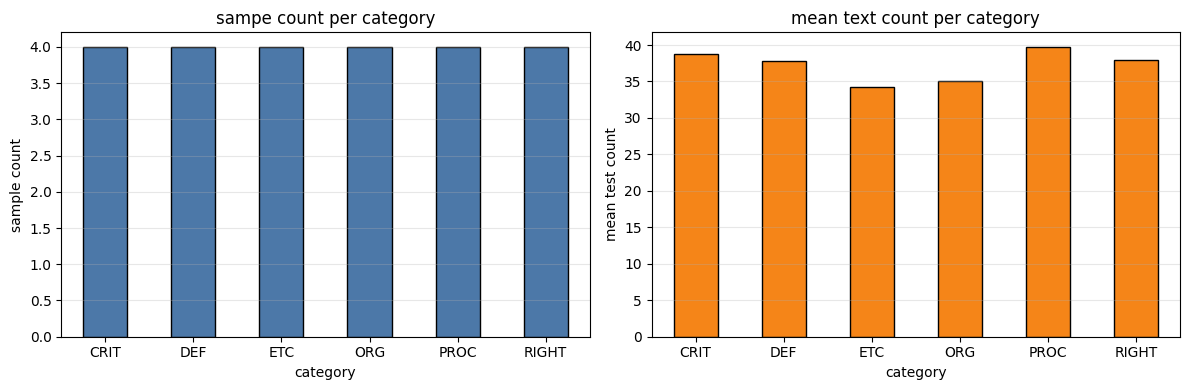

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

category_counts.plot(kind='bar', ax=axes[0], color='#4C78A8', edgecolor='black')
axes[0].set_title('sampe count per category')
axes[0].set_xlabel('category')
axes[0].set_ylabel('sample count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

mean_length = df.groupby('category')['length'].mean().sort_index()
mean_length.plot(kind='bar', ax=axes[1], color='#F58518', edgecolor='black')
axes[1].set_title('mean text count per category')
axes[1].set_xlabel('category')
axes[1].set_ylabel('mean test count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# 카테고리별 대표 문장과 토큰확인
# 법률문장 분류에서는 처한다 위원회  이상 시행한다 같은 표현이 중요한 단서가됨
# 단어하나만으로는 충분하지 않으므로 문장 전체의 기능을 같이 봐야 함

for category in sorted(df['category'].unique()):
    row = df[df['category'] == category].iloc[0]
    name = category_df.set_index('code').loc[category, 'name']
    print(f'[{category}] {name}')
    print(f'문장: {row["text"]}')
    print(f'토큰({row["token_count"]}개): {row["tokens"]}')
    print('-' * 80)

[CRIT] 기준 및 요건
문장: 후보자는 선거일 현재 25세 이상인 국민이어야 한다.
토큰(7개): ['후보자는', '선거일', '현재', '25세', '이상인', '국민이어야', '한다']
--------------------------------------------------------------------------------
[DEF] 정의 및 범위
문장: 이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
토큰(11개): ['이', '법은', '국민의', '기본적', '인권을', '보호하고', '자유와', '평등을', '실현함을', '목적으로', '한다']
--------------------------------------------------------------------------------
[ETC] 기타 조항
문장: 이 법은 공포 후 6개월이 경과한 날부터 시행한다.
토큰(8개): ['이', '법은', '공포', '후', '6개월이', '경과한', '날부터', '시행한다']
--------------------------------------------------------------------------------
[ORG] 조직 및 기구
문장: 분쟁 조정을 위하여 국무총리 소속으로 조정위원회를 둔다.
토큰(7개): ['분쟁', '조정을', '위하여', '국무총리', '소속으로', '조정위원회를', '둔다']
--------------------------------------------------------------------------------
[PROC] 절차 및 처벌
문장: 이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.
토큰(12개): ['이', '법을', '위반한', '자는', '3년', '이하의', '징역', '또는', '3천만원', '이하의', '벌금에', '처한다']
-----------------------------------------------------

**목적**: 카테고리 정의표의 대표 표현이 실제 샘플에 얼마나 등장하는지 확인합니다.

**Why?** 프롬프트에 카테고리 정의를 넣을 때는 추상적인 설명만 쓰는 것보다 대표 표현을 함께 제시하는 편이 안정적입니다. 단, 대표 표현은 힌트일 뿐 정답 규칙이 아닙니다.

**반환값 설명**:
- `signal_hits`: 각 카테고리의 대표 표현이 전체 데이터에서 발견된 횟수입니다.
- 이 값이 0이어도 해당 카테고리가 틀렸다는 뜻은 아닙니다. 표현이 다른 방식으로 쓰였을 수 있습니다.

In [25]:
signal_rows = []
for _, info in category_df.iterrows():
    for signal in info['signals']:
        hit_count = df['text'].str.contains(re.escape(signal), regex=True).sum()
        signal_rows.append({
            'category': info['code'],
            'signal': signal,
            'hit_count': int(hit_count),
        })

signal_df = pd.DataFrame(signal_rows)
signal_df.sort_values(['category', 'hit_count'], ascending=[True, False])


,category,signal,hit_count
24,CRIT,이상,3
21,CRIT,기준,1
23,CRIT,자격,1
25,CRIT,이하,1
22,CRIT,요건,0
3,DEF,적용,2
0,DEF,목적,1
1,DEF,정의,0
2,DEF,뜻한다,0
4,DEF,범위,0


## 카테고리별 구분 단어 분석

**목적**: 단순히 단어를 세는 데서 끝내지 않고, 어떤 표현이 특정 카테고리를 다른 카테고리와 구분하는지 계산합니다.

**Why?** 많이 등장하는 단어가 항상 좋은 분류 단서는 아닙니다. 예를 들어 `이`, `법`, `한다`는 여러 카테고리에 넓게 나타나므로 구분력이 약합니다. 반대로 `징역`, `위원회`, `시행`처럼 특정 카테고리에 치우친 표현은 분류 근거로 더 유용합니다.

**계산 방식**:
- `category_count`: 해당 카테고리에서 그 토큰이 등장한 문장 수입니다.
- `other_count`: 다른 카테고리에서 그 토큰이 등장한 문장 수입니다.
- `lift`: 특정 카테고리에서 상대적으로 얼마나 더 자주 등장하는지 나타내는 값입니다.
- `lift`가 높을수록 그 카테고리를 구분하는 단서로 볼 수 있습니다.

In [26]:
# 너무 일반적인 법률/문장 표현은 구분 단어 분석에서 제외합니다.
stopwords = {
    '이', '그', '및', '또는', '한다', '있다', '없는', '있는', '따른', '따라', '위하여',
    '법', '법은', '법을', '자는', '날부터', '경우', '각', '호와', '같다'
}

# 같은 문장 안에서 반복된 토큰은 1번만 센다. 문장 수 기준으로 보기 위해서입니다.
doc_token_rows = []
for _, row in df.iterrows():
    unique_tokens = sorted(set(row['tokens']) - stopwords)
    for token in unique_tokens:
        if len(token) < 2:
            continue
        doc_token_rows.append({'id': row['id'], 'category': row['category'], 'token': token})

doc_token_df = pd.DataFrame(doc_token_rows)

discriminative_rows = []
for category in sorted(df['category'].unique()):
    category_doc_count = (df['category'] == category).sum()
    other_doc_count = (df['category'] != category).sum()
    for token in sorted(doc_token_df['token'].unique()):
        category_count = doc_token_df[(doc_token_df['category'] == category) & (doc_token_df['token'] == token)]['id'].nunique()
        other_count = doc_token_df[(doc_token_df['category'] != category) & (doc_token_df['token'] == token)]['id'].nunique()
        if category_count == 0:
            continue
        # 라플라스 보정으로 0 나누기와 과도한 무한대 점수를 피합니다.
        category_rate = (category_count + 1) / (category_doc_count + 2)
        other_rate = (other_count + 1) / (other_doc_count + 2)
        lift = category_rate / other_rate
        discriminative_rows.append({
            'category': category,
            'token': token,
            'category_count': int(category_count),
            'other_count': int(other_count),
            'lift': round(lift, 2),
        })

discriminative_df = pd.DataFrame(discriminative_rows)

top_terms = (
    discriminative_df
    .sort_values(['category', 'lift', 'category_count'], ascending=[True, False, False])
    .groupby('category')
    .head(6)
    .reset_index(drop=True)
)

top_terms

,category,token,category_count,other_count,lift
0,CRIT,1억원,1,0,7.33
1,CRIT,25세,1,0,7.33
2,CRIT,2명,1,0,7.33
3,CRIT,갖추어야,1,0,7.33
4,CRIT,경력,1,0,7.33
5,CRIT,국민이어야,1,0,7.33
6,DEF,공공기관이란,1,0,7.33
7,DEF,국가기관,1,0,7.33
8,DEF,국민의,1,0,7.33
9,DEF,기관을,1,0,7.33


## : 문장별 라벨 점수표 만들기

**목적**: 규칙 기반 분류기가 왜 특정 라벨을 골랐는지 점수표로 확인합니다.

**Why?** `예측=PROC` 같은 결과만 보면 분석이 아니라 출력 확인에 가깝습니다. 라벨별 점수를 같이 보면 어떤 키워드가 어느 라벨을 끌어올렸고, 1등과 2등의 차이가 얼마나 작은지 확인할 수 있습니다.

**출력 해석**:
- `score_*`: 각 카테고리 키워드가 문장에 몇 개 맞았는지 나타냅니다.
- `top_category`: 가장 높은 점수를 받은 라벨입니다.
- `runner_up`: 두 번째 후보 라벨입니다.
- `margin`: 1등 점수와 2등 점수의 차이입니다. 작을수록 애매한 문장입니다.
- `matched_keywords`: 실제로 매칭된 키워드입니다.

In [27]:
def score_by_category(text, rules):
    score = {}
    matched = {}
    for category, keywords in rules.items():
        hits = [keyword for keyword in keywords if keyword in text]
        score[category] = len(hits)
        matched[category] = hits
    return score, matched

def analyze_rule_scores(text):
    score, matched = score_by_category(text, keyword_rules)
    ranked = sorted(score.items(), key=lambda item: (-item[1], item[0]))
    top_category, top_score = ranked[0]
    runner_up, runner_score = ranked[1]
    return {
        'top_category': top_category if top_score > 0 else 'ETC',
        'top_score': top_score,
        'runner_up': runner_up,
        'runner_up_score': runner_score,
        'margin': top_score - runner_score,
        'matched_keywords': {cat: words for cat, words in matched.items() if words},
        **{f'score_{cat}': score[cat] for cat in sorted(keyword_rules)},
    }

score_df = pd.DataFrame([analyze_rule_scores(text) for text in df['text']])
scored_df = pd.concat([df[['id', 'category', 'text']], score_df], axis=1)

scored_df[['id', 'category', 'top_category', 'runner_up', 'margin', 'matched_keywords', 'text']]

,id,category,top_category,runner_up,margin,matched_keywords,text
0,D01,DEF,DEF,CRIT,1,{'DEF': ['목적']},이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
1,D02,DEF,DEF,CRIT,1,{'DEF': ['뜻']},이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.
2,D03,DEF,ORG,DEF,1,"{'DEF': ['말한다'], 'ORG': ['기관', '설치']}","공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
3,D04,DEF,DEF,CRIT,1,{'DEF': ['적용한다']},이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.
4,R01,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['차별']},"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ..."
5,R02,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['하여야 한다']},사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.
6,R03,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['권리']},근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.
7,R04,RIGHT,RIGHT,CRIT,1,{'RIGHT': ['침해']},누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.
8,P01,PROC,PROC,CRIT,2,"{'CRIT': ['이하'], 'PROC': ['징역', '벌금', '처한다']}",이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.
9,P02,PROC,CRIT,PROC,0,"{'CRIT': ['이내'], 'PROC': ['신청']}",신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.


##  모호도 분석

**목적**: 어떤 문장이 분류하기 쉬운지, 어떤 문장이 검토가 필요한지 자동으로 표시합니다.

**Why?** 실무에서는 모든 예측을 같은 신뢰도로 다루면 안 됩니다. 1등과 2등 라벨 점수가 비슷한 문장은 사람이 재검토하거나 LLM에게 근거를 요청해야 합니다.

**판정 기준**:
- `no_signal`: 어떤 규칙에도 걸리지 않은 문장입니다.
- `ambiguous`: 1등과 2등 점수 차이가 1 이하인 문장입니다.
- `confident_rule`: 규칙상 비교적 뚜렷한 문장입니다.

In [28]:
def ambiguity_label(row):
    if row['top_score'] == 0:
        return 'no_signal'
    if row['margin'] <= 1 and row['runner_up_score'] > 0:
        return 'ambiguous'
    return 'confident_rule'

scored_df['ambiguity'] = scored_df.apply(ambiguity_label, axis=1)

ambiguity_summary = scored_df.groupby(['category', 'ambiguity']).size().unstack(fill_value=0)
print('카테고리별 모호도 요약')
print(ambiguity_summary)

print('\n검토 우선순위가 높은 문장')
review_targets = scored_df[scored_df['ambiguity'] != 'confident_rule'][
    ['id', 'category', 'top_category', 'runner_up', 'margin', 'ambiguity', 'matched_keywords', 'text']
]
review_targets

카테고리별 모호도 요약
ambiguity  ambiguous  confident_rule
category                            
CRIT               1               3
DEF                1               3
ETC                1               3
ORG                1               3
PROC               1               3
RIGHT              0               4

검토 우선순위가 높은 문장


,id,category,top_category,runner_up,margin,ambiguity,matched_keywords,text
2,D03,DEF,ORG,DEF,1,ambiguous,"{'DEF': ['말한다'], 'ORG': ['기관', '설치']}","공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
9,P02,PROC,CRIT,PROC,0,ambiguous,"{'CRIT': ['이내'], 'PROC': ['신청']}",신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.
13,O02,ORG,ORG,CRIT,1,ambiguous,"{'ORG': ['위원회', '구성'], 'CRIT': ['이내']}",위원회는 위원장 1명을 포함한 15명 이내의 위원으로 구성한다.
18,C03,CRIT,CRIT,ETC,0,ambiguous,"{'CRIT': ['기준'], 'ETC': ['대통령령으로 정한다']}","안전관리 기준은 시설 면적, 이용 인원 및 위험도에 따라 대통령령으로 정한다."
23,E04,ETC,DEF,ETC,0,ambiguous,"{'DEF': ['적용한다'], 'ETC': ['시행']}",제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.


##  규칙 기반 기준선 분류기 만들기

**목적**: 대표 표현이 포함되어 있으면 해당 카테고리로 예측하는 단순 분류기를 만듭니다.

**Why?** 기준선은 나중에 LLM 프롬프트 결과와 비교할 최소 성능입니다. 단순 규칙도 일부 문장은 맞히지만, 문맥과 우선순위가 필요한 문장에서는 쉽게 실패합니다.

**주요 파라미터**:
- `keyword_rules`: 카테고리별 탐지 키워드 목록입니다.
- `text`: 분류할 한 문장입니다.

**반환값**:
- 예측 카테고리 코드 1개입니다.
- 어떤 규칙도 맞지 않으면 `ETC`를 반환합니다.

In [29]:
# 우선순위가 있는 규칙 기반 분류기입니다.
# CRIT의 '이하', '이내' 같은 수치 표현이 처벌 조항에도 등장하므로,
# 실제 운영에서는 우선순위 설계가 성능에 큰 영향을 줍니다.
def rule_based_classify(text, priority=None):
    priority = priority or ['DEF', 'ORG', 'CRIT', 'PROC', 'RIGHT', 'ETC']
    score, _ = score_by_category(text, keyword_rules)
    for category in priority:
        if score[category] > 0:
            return category
    return 'ETC'

def evaluate_predictions(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    rows = []
    for label in labels:
        tp = sum((yt == label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fp = sum((yt != label) and (yp == label) for yt, yp in zip(y_true, y_pred))
        fn = sum((yt == label) and (yp != label) for yt, yp in zip(y_true, y_pred))
        precision = tp / (tp + fp) if (tp + fp) else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
        rows.append({
            'category': label,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'precision': round(precision, 2),
            'recall': round(recall, 2),
            'f1': round(f1, 2),
        })
    return pd.DataFrame(rows)

df['rule_pred'] = df['text'].apply(rule_based_classify)
df['rule_correct'] = df['category'] == df['rule_pred']

accuracy = df['rule_correct'].mean()
print(f'규칙 기반 기준선 정확도: {accuracy:.1%}')

metrics_df = evaluate_predictions(df['category'], df['rule_pred'])
print('\n카테고리별 성능 지표')
print(metrics_df)

df[['id', 'category', 'rule_pred', 'rule_correct', 'text']]

규칙 기반 기준선 정확도: 87.5%

카테고리별 성능 지표
  category  tp  fp  fn  precision  recall    f1
0     CRIT   4   2   0       0.67    1.00  0.80
1      DEF   4   1   0       0.80    1.00  0.89
2      ETC   3   0   1       1.00    0.75  0.86
3      ORG   4   0   0       1.00    1.00  1.00
4     PROC   2   0   2       1.00    0.50  0.67
5    RIGHT   4   0   0       1.00    1.00  1.00


,id,category,rule_pred,rule_correct,text
0,D01,DEF,DEF,True,이 법은 국민의 기본적 인권을 보호하고 자유와 평등을 실현함을 목적으로 한다.
1,D02,DEF,DEF,True,이 법에서 사용하는 용어의 뜻은 다음 각 호와 같다.
2,D03,DEF,DEF,True,"공공기관이란 국가기관, 지방자치단체 및 법령에 따라 설치된 기관을 말한다."
3,D04,DEF,DEF,True,이 법은 대한민국 영역 안에서 이루어지는 정보 처리 행위에 적용한다.
4,R01,RIGHT,RIGHT,True,"모든 국민은 법 앞에 평등하며 성별, 종교 또는 사회적 신분에 의하여 차별을 받지 ..."
5,R02,RIGHT,RIGHT,True,사업자는 이용자의 개인정보를 안전하게 관리하여야 한다.
6,R03,RIGHT,RIGHT,True,근로자는 안전하고 건강한 근무 환경에서 일할 권리를 가진다.
7,R04,RIGHT,RIGHT,True,누구든지 정당한 사유 없이 타인의 통신비밀을 침해하여서는 아니 된다.
8,P01,PROC,CRIT,False,이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.
9,P02,PROC,CRIT,False,신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.


##  오류 사례와 성능 지표 분석

**목적**: 규칙 기반 분류기가 틀린 문장을 직접 확인합니다.

**Why?** 오류 분석은 모델 개선의 출발점입니다. 어떤 문장이 왜 틀렸는지 알아야 다음 차시에서 프롬프트 정의, 예시, 출력 형식을 개선할 수 있습니다.

**출력 해석**:
- `정답`: 사람이 붙인 기준 라벨입니다.
- `예측`: 단순 규칙이 고른 라벨입니다.
- 정답과 예측이 다르면 카테고리 경계 또는 키워드 우선순위를 다시 봐야 합니다.

In [30]:
errors = df[df['rule_correct'] == False].copy()

if errors.empty:
    print('현재 샘플에서는 규칙 기반 분류기가 모두 맞혔습니다. 하지만 새 문장에서는 실패할 수 있습니다.')
else:
    error_details = []
    for _, row in errors.iterrows():
        score, matched = score_by_category(row['text'], keyword_rules)
        error_details.append({
            'id': row['id'],
            'true': row['category'],
            'pred': row['rule_pred'],
            'true_score': score[row['category']],
            'pred_score': score[row['rule_pred']],
            'matched_keywords': {cat: words for cat, words in matched.items() if words},
            'text': row['text'],
        })
    error_df = pd.DataFrame(error_details)
    print(f'오류 {len(error_df)}건')
    print(error_df[['id', 'true', 'pred', 'true_score', 'pred_score', 'matched_keywords', 'text']])

confusion = pd.crosstab(df['category'], df['rule_pred'], rownames=['정답'], colnames=['예측'], dropna=False)
print('\n혼동 행렬')
print(confusion)
confusion

오류 3건
    id  true  pred  true_score  pred_score  \
0  P01  PROC  CRIT           3           1   
1  P02  PROC  CRIT           1           1   
2  E04   ETC   DEF           1           1   

                                matched_keywords  \
0  {'CRIT': ['이하'], 'PROC': ['징역', '벌금', '처한다']}   
1               {'CRIT': ['이내'], 'PROC': ['신청']}   
2               {'DEF': ['적용한다'], 'ETC': ['시행']}   

                                         text  
0  이 법을 위반한 자는 3년 이하의 징역 또는 3천만원 이하의 벌금에 처한다.  
1    신청인은 처분 통지를 받은 날부터 30일 이내에 이의신청을 할 수 있다.  
2      제3조의 개정규정은 이 법 시행 후 최초로 접수된 사건부터 적용한다.  

혼동 행렬
예측     CRIT  DEF  ETC  ORG  PROC  RIGHT
정답                                     
CRIT      4    0    0    0     0      0
DEF       0    4    0    0     0      0
ETC       0    1    3    0     0      0
ORG       0    0    0    4     0      0
PROC      2    0    0    0     2      0
RIGHT     0    0    0    0     0      4


예측,CRIT,DEF,ETC,ORG,PROC,RIGHT
정답,,,,,,
CRIT,4,0,0,0,0,0
DEF,0,4,0,0,0,0
ETC,0,1,3,0,0,0
ORG,0,0,0,4,0,0
PROC,2,0,0,0,2,0
RIGHT,0,0,0,0,0,4


##  규칙 우선순위 실험

**목적**: 같은 키워드 규칙이라도 우선순위를 바꾸면 성능이 어떻게 달라지는지 실험합니다.

**Why?** `이하`, `이내`는 기준·요건(`CRIT`)의 단서이지만, 처벌 조항(`PROC`)에도 자주 등장합니다. 이처럼 법률 텍스트에서는 키워드가 겹치기 때문에 단순 규칙보다 라벨 판정 순서와 문맥 해석이 중요합니다.

**분석 포인트**:
- 가장 좋은 우선순위와 가장 나쁜 우선순위의 정확도를 비교합니다.
- 성능 차이가 크다면, 키워드 방식이 불안정하다는 뜻입니다.

In [31]:
import itertools

labels_without_etc = ['DEF', 'RIGHT', 'PROC', 'ORG', 'CRIT']
priority_results = []

for priority_prefix in itertools.permutations(labels_without_etc):
    priority = list(priority_prefix) + ['ETC']
    preds = [rule_based_classify(text, priority=priority) for text in df['text']]
    acc = np.mean([yt == yp for yt, yp in zip(df['category'], preds)])
    priority_results.append({
        'priority': ' > '.join(priority),
        'accuracy': round(float(acc), 3),
    })

priority_df = pd.DataFrame(priority_results).sort_values('accuracy', ascending=False)

print('상위 우선순위 조합')
print(priority_df.head(5))
print('\n하위 우선순위 조합')
print(priority_df.tail(5))

print('\n정확도 분포')
print(priority_df['accuracy'].describe().round(3))

상위 우선순위 조합
                                 priority  accuracy
0   DEF > RIGHT > PROC > ORG > CRIT > ETC     0.958
2   DEF > RIGHT > ORG > PROC > CRIT > ETC     0.958
6   DEF > PROC > RIGHT > ORG > CRIT > ETC     0.958
15  DEF > ORG > PROC > CRIT > RIGHT > ETC     0.958
12  DEF > ORG > RIGHT > PROC > CRIT > ETC     0.958

하위 우선순위 조합
                                  priority  accuracy
115  CRIT > ORG > DEF > PROC > RIGHT > ETC     0.792
116  CRIT > ORG > RIGHT > DEF > PROC > ETC     0.792
117  CRIT > ORG > RIGHT > PROC > DEF > ETC     0.792
118  CRIT > ORG > PROC > DEF > RIGHT > ETC     0.792
119  CRIT > ORG > PROC > RIGHT > DEF > ETC     0.792

정확도 분포
count    120.000
mean       0.875
std        0.054
min        0.792
25%        0.833
50%        0.875
75%        0.917
max        0.958
Name: accuracy, dtype: float64


##  애매한 실제형 문장 검증

**목적**: 학습 데이터보다 더 애매한 문장을 넣고 사람이 직접 판단해 봅니다.

**Why?** 실무 데이터는 교과서처럼 한 라벨 신호만 담고 있지 않습니다. 권리와 요건, 조직과 절차, 기준과 위임이 한 문장에 같이 나타납니다.

**활동 방법**:
1. `expected_options`를 보기 전에 먼저 스스로 라벨을 예측합니다.
2. 규칙 기반 예측과 비교합니다.
3. 어떤 정보가 추가되면 더 확신할 수 있을지 적어 봅니다.

In [32]:
ambiguous_cases = pd.DataFrame([
    {
        'case_id': 'A01',
        'text': '사업자는 안전관리 기준을 충족한 경우에만 서비스를 제공할 수 있다.',
        'expected_options': 'CRIT 또는 RIGHT',
        'note': '조건이 핵심이면 CRIT, 사업자의 의무/가능 행위가 핵심이면 RIGHT',
    },
    {
        'case_id': 'A02',
        'text': '위원회는 신청인의 이의신청을 접수한 날부터 30일 이내에 심의하여야 한다.',
        'expected_options': 'ORG 또는 PROC',
        'note': '위원회 권한 설명이면 ORG, 이의신청 처리 흐름이면 PROC',
    },
    {
        'case_id': 'A03',
        'text': '세부 안전관리 기준은 대통령령으로 정한다.',
        'expected_options': 'CRIT 또는 ETC',
        'note': '기준 내용이 직접 제시되지 않고 위임만 있으면 ETC에 가까움',
    },
    {
        'case_id': 'A04',
        'text': '개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.',
        'expected_options': 'RIGHT 또는 PROC',
        'note': '정보주체 권리 보장이 핵심이면 RIGHT, 청구 절차가 핵심이면 PROC',
    },
])

ambiguous_cases['rule_pred'] = ambiguous_cases['text'].apply(rule_based_classify)
ambiguous_cases

,case_id,text,expected_options,note,rule_pred
0,A01,사업자는 안전관리 기준을 충족한 경우에만 서비스를 제공할 수 있다.,CRIT 또는 RIGHT,"조건이 핵심이면 CRIT, 사업자의 의무/가능 행위가 핵심이면 RIGHT",CRIT
1,A02,위원회는 신청인의 이의신청을 접수한 날부터 30일 이내에 심의하여야 한다.,ORG 또는 PROC,"위원회 권한 설명이면 ORG, 이의신청 처리 흐름이면 PROC",ORG
2,A03,세부 안전관리 기준은 대통령령으로 정한다.,CRIT 또는 ETC,기준 내용이 직접 제시되지 않고 위임만 있으면 ETC에 가까움,CRIT
3,A04,개인정보처리자는 정보주체의 열람 청구 절차를 지체 없이 안내하여야 한다.,RIGHT 또는 PROC,"정보주체 권리 보장이 핵심이면 RIGHT, 청구 절차가 핵심이면 PROC",PROC


## NEXT

LLM에게 단순히 “분류해줘”라고 요청하면 라벨 경계를 자기 방식으로 해석할 수 있습니다. 좋은 프롬프트는 데이터 분석에서 발견한 혼동 지점을 명시적으로 줄여 줍니다.

**정리할 항목**:
- 카테고리 정의를 그대로 넣을 것인가, 짧게 요약할 것인가
- 애매한 사례에서 우선순위를 줄 것인가
- 출력은 코드만 받을 것인가, 근거까지 받을 것인가
- 사람이 검토해야 할 낮은 확신 사례를 어떻게 표시할 것인가